In [1]:

# Importing required libraries 
import numpy as np 
import pandas as pd 
import matplotlib as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Read the dataset 
sea_passanger = pd.read_csv('2020-2025.csv',
                            index_col ='Tahun', 
                            parse_dates = True) 
  


C:\Users\athiy\AppData\Local\Temp\ipykernel_25464\3404302964.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sea_passanger = pd.read_csv('2020-2025.csv',


In [2]:
# Print the first five rows of the dataset 
sea_passanger
  

,Penumpang
Tahun,
2020-01-01,18821
2020-02-01,14667
2020-03-01,17103
2020-04-01,5024
2020-05-01,2267
...,...
2024-11-01,23251
2024-12-01,25349
2025-01-01,18614


In [3]:
sea_passanger.describe()

,Penumpang
count,63.000000
mean,22934.492063
std,12850.799544
min,2267.000000
25%,13731.000000
50%,19754.000000
75%,32522.000000
max,61649.000000


In [5]:
# univariate data preparation
from numpy import array

# split a univariate sequence into samples
def split_sequence(sequence, n_steps):
	X, y = list(), list()
	for i in range(len(sequence)):
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the sequence
		if end_ix > len(sequence)-1:
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
		X.append(seq_x)
		y.append(seq_y)
	return array(X), array(y)

# define input sequence
raw_seq = sea_passanger['Penumpang']
# choose a number of time steps
n_steps = 5
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# summarize the data
for i in range(len(X)):
	print(X[i], y[i])

[18821 14667 17103  5024  2267] 6527
[14667 17103  5024  2267  6527] 7977
[17103  5024  2267  6527  7977] 9174
[5024 2267 6527 7977 9174] 9272
[2267 6527 7977 9174 9272] 13432
[ 6527  7977  9174  9272 13432] 14311
[ 7977  9174  9272 13432 14311] 15029
[ 9174  9272 13432 14311 15029] 8787
[ 9272 13432 14311 15029  8787] 6169
[13432 14311 15029  8787  6169] 11589
[14311 15029  8787  6169 11589] 18451
[15029  8787  6169 11589 18451] 14728
[ 8787  6169 11589 18451 14728] 13411
[ 6169 11589 18451 14728 13411] 6632
[11589 18451 14728 13411  6632] 7479
[18451 14728 13411  6632  7479] 11997
[14728 13411  6632  7479 11997] 20035
[13411  6632  7479 11997 20035] 18133
[ 6632  7479 11997 20035 18133] 14605
[ 7479 11997 20035 18133 14605] 11669
[11997 20035 18133 14605 11669] 10981
[20035 18133 14605 11669 10981] 18918
[18133 14605 11669 10981 18918] 25609
[14605 11669 10981 18918 25609] 39180
[11669 10981 18918 25609 39180] 29620
[10981 18918 25609 39180 29620] 35030
[18918 25609 39180 29620 35030

C:\Users\athiy\AppData\Local\Temp\ipykernel_25464\1591396104.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]


In [5]:
from keras.layers import LSTM, Dense
from keras.models import Sequential

# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))


# define model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(n_steps, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


# fit model
model.fit(X, y, epochs=200, verbose=0)


ModuleNotFoundError: No module named 'tensorflow.python'

In [ ]:
# demonstrate prediction
x_input = array([70, 80, 90])
x_input = x_input.reshape((1, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)

C:\Users\athiy\AppData\Local\Temp\ipykernel_20580\3009500960.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_P['ds'] = pd.to_datetime(df['Tahun'])


,ds,y
0,2020-01-01,18821
1,2020-02-01,14667
2,2020-03-01,17103
3,2020-04-01,5024
4,2020-05-01,2267


In [ ]:
# Prepare data for comprehensive plotting
# Adjusted date ranges
train_dates = sea_passanger.index[look_back:train_size]
train_actual = sea_passanger.iloc[look_back:train_size]['Passengers']
train_predicted = pd.Series(train_predict[:,0], index=train_dates)

test_dates = sea_passanger.index[train_size+look_back:]
test_actual = sea_passanger.iloc[train_size+look_back:]['Passengers']
test_predicted = pd.Series(test_predict[:,0], index=test_dates)


10:16:41 - cmdstanpy - INFO - Chain [1] start processing
10:16:42 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# Future forecasting
def forecast_future(model, last_known_data, look_back, scaler, steps=12):
    current_batch = last_known_data[-look_back:]
    predictions = []
    
    for _ in range(steps):
        # Reshape the current batch
        current_input = current_batch.reshape((1, look_back, 1))
        
        # Predict next value
        pred = model.predict(current_input)
        
        # Inverse transform the prediction
        pred_actual = scaler.inverse_transform(pred)[0][0]
        predictions.append(pred_actual)
        
        # Update current batch
        current_batch = np.append(current_batch[1:], pred)
    
    return predictions



In [ ]:
# Perform future forecasting
last_known_data = scaled_data[-look_back:]
future_forecast = forecast_future(model, last_known_data, look_back, scaler)

# Create future dates
last_date = pd.to_datetime(sea_passanger.index[-1])
future_dates = pd.date_range(start=pd.to_datetime(last_date) + pd.Timedelta(days=1), periods=12, freq='M')
future_forecast_series = pd.Series(future_forecast, index=future_dates)

# Plotting
plt.figure(figsize=(15,6))
# Plot training actual and predicted
plt.plot(train_dates, train_actual, label='Training Actual', color='blue')
plt.plot(train_dates, train_predicted, label='Training Predicted', color='lightblue', linestyle='--')

# Plot testing actual and predicted
plt.plot(test_dates, test_actual, label='Testing Actual', color='green')
plt.plot(test_dates, test_predicted, label='Testing Predicted', color='lightgreen', linestyle='--')

# Plot future forecast
plt.plot(future_dates, future_forecast_series, label='Future Forecast', color='red', linestyle=':')

plt.title('Sea Passengers: Actual vs Predicted with Future Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_predictions.png')


,ds,yhat,yhat_lower,yhat_upper,trend,trend_lower,trend_upper
82,2026-10-31,38463.559897,29220.478273,47378.214649,50499.359724,50498.964902,50499.711211
83,2026-11-30,54432.246304,45514.396009,63860.978866,51000.236383,50999.803874,51000.615678
84,2026-12-31,51646.736188,41954.547701,60987.101351,51517.808932,51517.344191,51518.217956
85,2027-01-31,52164.546470,42910.248634,61549.482156,52035.381481,52034.878512,52035.825091
86,2027-02-28,24887.986654,15259.139462,34513.667175,52502.866363,52502.325547,52503.344389


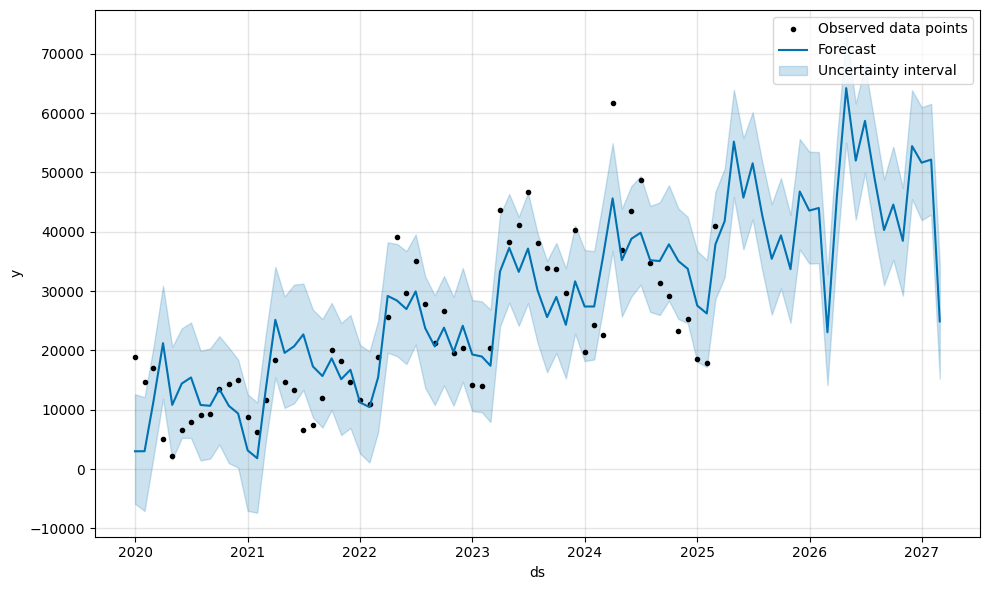

In [ ]:
# Print evaluation metrics
print("Training Metrics:")
print(f"MAE: {train_mae:.2f}")
print(f"MSE: {train_mse:.2f}")
print(f"RMSE: {train_rmse:.2f}")

print("\nTesting Metrics:")
print(f"MAE: {test_mae:.2f}")
print(f"MSE: {test_mse:.2f}")
print(f"RMSE: {test_rmse:.2f}")